In [86]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from trunx.config import project_root
from trunx.gp3.PG3_model_impl import run_threepg_main
from trunx.gp3.plot_function import create_comparison_dataframe
from trunx.gp3.run_r3pg import run_comparison_r

os.chdir(project_root)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
file_path = "./data/data_sspecies_nothinning.xlsx"
# fig, outputs, df = run_threepg_main(file_path, plot_output=True, r_comparison = True)

File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx
Final stem biomass (Mg/ha): [165.85802]
Final LAI: [0.]
Final WS: [165.85802]
Fagus sylvatica: [∂WS/∂alphaCx, ∂WS/∂CoeffCond, ∂WS/∂Y] = [[1942.6405 ]
 [-594.71967]
 [ 205.8788 ]]
File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx


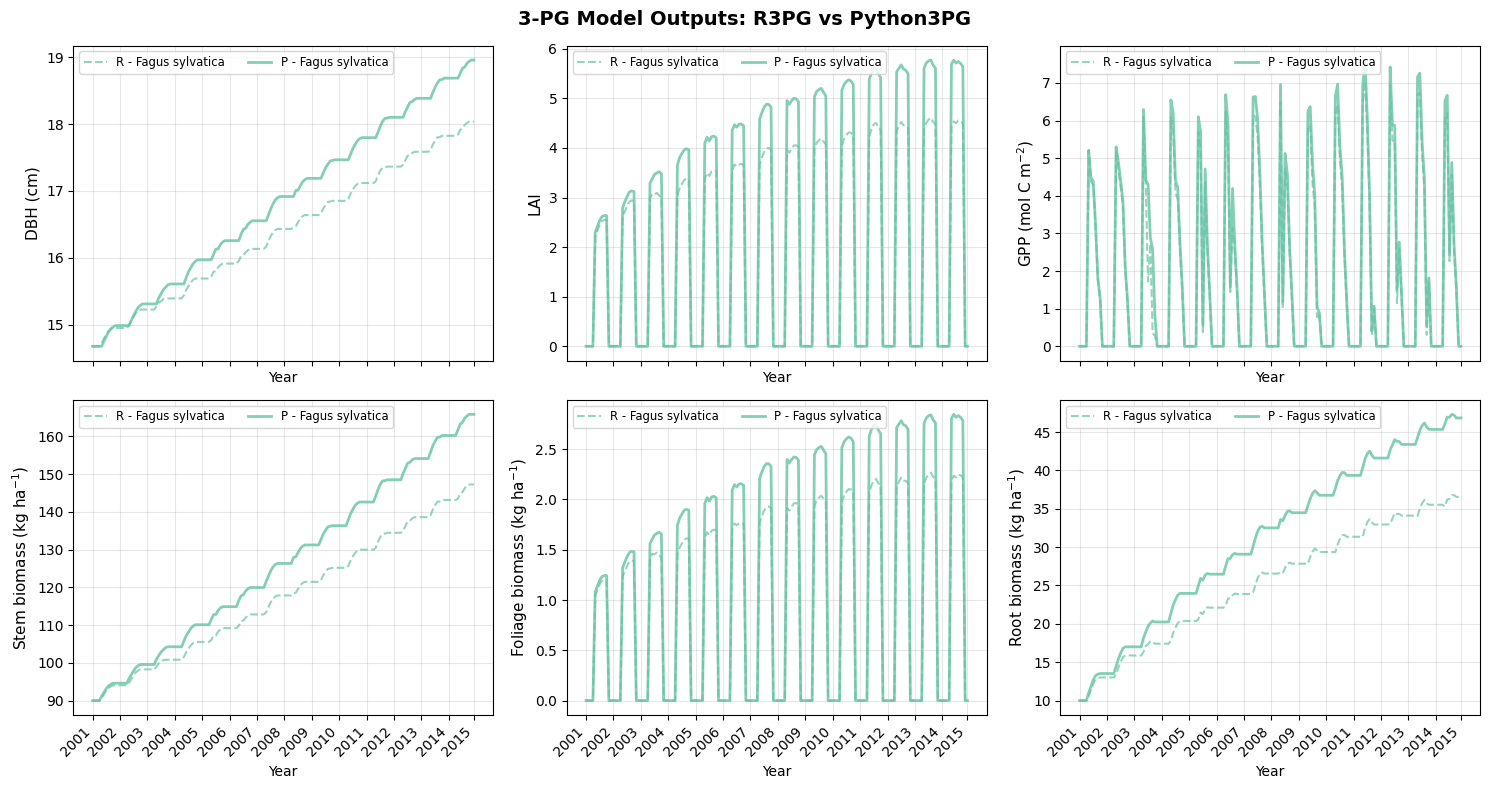

In [88]:
r_df = run_comparison_r(file_path)
fig, outputs = run_threepg_main(file_path, plot_output=True, r_comparison=True)

df = create_comparison_dataframe(r_df, outputs, np.datetime64("2001-01"))

# df.head()

Final stem biomass (Mg/ha): [165.85802]
Final LAI: [0.]
Final WS: [165.85802]
Fagus sylvatica: [∂WS/∂alphaCx, ∂WS/∂CoeffCond, ∂WS/∂Y] = [[1942.6405 ]
 [-594.71967]
 [ 205.8788 ]]
File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx


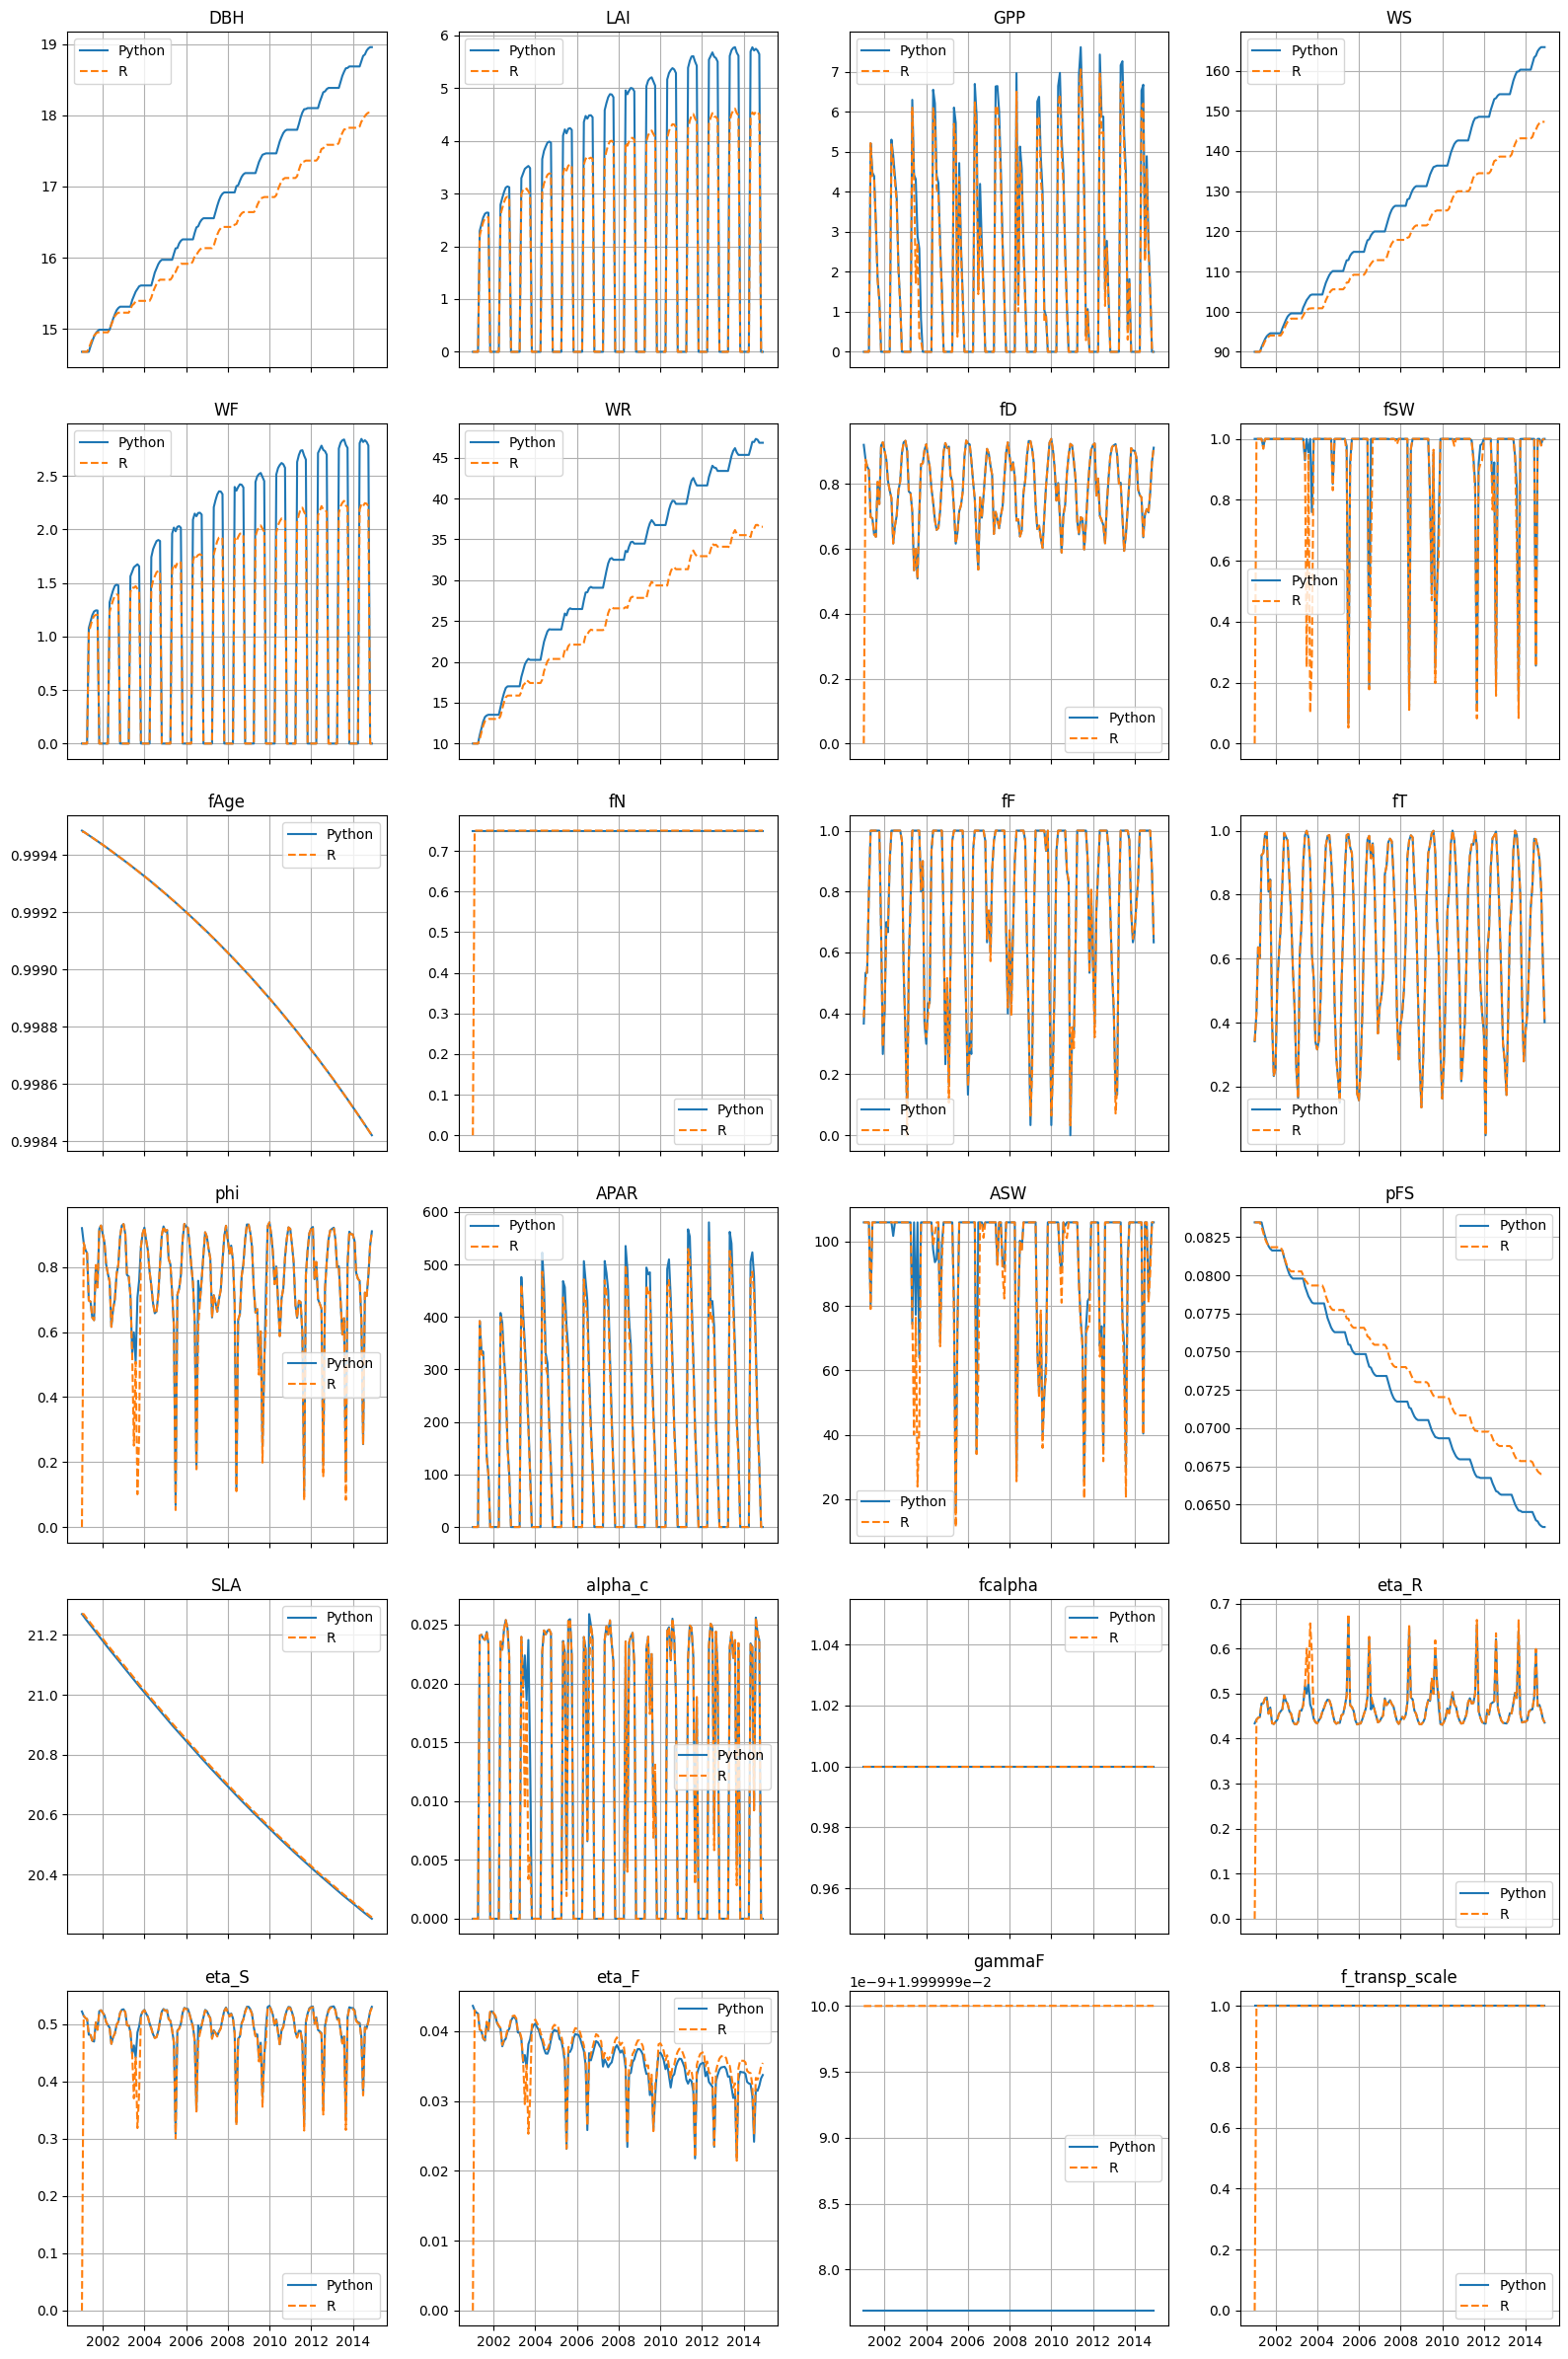

In [91]:
file_path = "./data/data_sspecies_nothinning.xlsx"

fig, outputs = run_threepg_main(file_path, plot_output=False, r_comparison=True)

# Ensure Dates column is datetime
df = pd.read_csv("./data/r_python.comparison.csv")
df["Dates"] = pd.to_datetime(df["Dates"])

py_metrics = [
    col for col in df.columns if not col.startswith("r_") and col != "Dates" and col != "species"
]

ncols = 4
n_metrics = len(py_metrics)
nrows = (n_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, py_col in zip(axes, py_metrics, strict=False):
    r_col = f"r_{py_col}"
    if r_col in df.columns:
        ax.plot(df["Dates"], df[py_col], label="Python", color="tab:blue")
        ax.plot(df["Dates"], df[r_col], label="R", color="tab:orange", linestyle="--")
        ax.set_title(py_col)
        ax.grid(True)
        ax.legend()

for i in range(len(py_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()